# Merit-order effect in the German day-ahead market (DE-LU, 2019–2025)

**Research question.** Does a higher renewable (wind + solar) generation share reduce German day-ahead
electricity prices via merit-order displacement, and has this effect strengthened between 2019–2021 and 2022–2025?

Data: ENTSO-E Transparency Platform (`entsoe-py`), bidding zone DE-LU, hourly. Requires `ENTSOE_API_KEY` to be
set in `.env`; see `.env.example`.

## 1. Setup

In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from dotenv import load_dotenv
from IPython.display import display

load_dotenv()  # reads ENTSOE_API_KEY from a local .env (never committed)
API_KEY = (os.getenv("ENTSOE_API_KEY") or "").strip()
if API_KEY in {"", "your_key_here"}:
    raise RuntimeError(
        "ENTSOE_API_KEY is missing or not set. Copy .env.example to .env and set "
        "ENTSOE_API_KEY to a valid ENTSO-E Transparency Platform key."
    )

COUNTRY = "DE_LU"
TZ = "Europe/Berlin"
START_YEAR, END_YEAR = 2019, 2025
START_LOCAL = pd.Timestamp(f"{START_YEAR}-01-01", tz=TZ)
END_LOCAL = pd.Timestamp(f"{END_YEAR + 1}-01-01", tz=TZ)   # exclusive
SUBPERIODS = {"2019–2021": (2019, 2021), "2022–2025": (2022, 2025)}
HAC_MAXLAGS = 168          # Newey-West truncation lag, in hours (one week)
DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

print("ENTSOE_API_KEY found — using real ENTSO-E data (cached in ./data after the first pull).")

ENTSOE_API_KEY found — using real ENTSO-E data (cached in ./data after the first pull).


## 2. Data
**Real data.** Pulled one calendar year at a time (local time) and cached raw to `data/<series>_<year>.parquet`,
so re-runs never hit the API again. Timezone handling: raw series arrive tz-aware in Europe/Berlin; they are
converted to UTC before resampling to hourly means (UTC has no DST gaps or repeated hours; this also aggregates the
15-minute generation/load series and the 15-minute day-ahead prices introduced in October 2025). Calendar features
are then derived from the Europe/Berlin local time, so CET/CEST transition days have 23 or 25 hourly observations.
Negative prices are kept as-is — never dropped or clipped.

In [2]:
def _to_hourly_utc(obj):
    """Drop duplicate timestamps (year-boundary overlaps), convert to UTC, hourly mean."""
    obj = obj[~obj.index.duplicated(keep="first")].sort_index()
    obj.index = obj.index.tz_convert("UTC")
    return obj.resample("1h").mean()


def _cached(name, year, fetch):
    path = DATA_DIR / f"{name}_{year}.parquet"
    if path.exists():
        return pd.read_parquet(path)
    print(f"  pulling {name} {year} from ENTSO-E ...")
    df = fetch(year)
    df.to_parquet(path)
    return df


def load_real_data():
    from entsoe import EntsoePandasClient
    client = EntsoePandasClient(api_key=API_KEY)

    def bounds(y):
        return pd.Timestamp(f"{y}-01-01", tz=TZ), pd.Timestamp(f"{y + 1}-01-01", tz=TZ)

    def fetch_price(y):
        s, e = bounds(y)
        return client.query_day_ahead_prices(COUNTRY, start=s, end=e).rename("price").to_frame()

    def fetch_gen(y):
        s, e = bounds(y)
        g = client.query_generation(COUNTRY, start=s, end=e, psr_type=None)
        if isinstance(g.columns, pd.MultiIndex):
            # keep generation, drop 'Actual Consumption' (e.g. pumped-storage pumping)
            g = g.xs("Actual Aggregated", axis=1, level=1)
        g.columns = [str(c) for c in g.columns]
        return g

    def fetch_load(y):
        s, e = bounds(y)
        l = client.query_load(COUNTRY, start=s, end=e)
        if isinstance(l, pd.Series):
            l = l.to_frame("Actual Load")
        return l[["Actual Load"]].rename(columns={"Actual Load": "load"})

    years = range(START_YEAR, END_YEAR + 1)
    price = _to_hourly_utc(pd.concat([_cached("price", y, fetch_price) for y in years]))
    gen = _to_hourly_utc(pd.concat([_cached("generation", y, fetch_gen) for y in years]))
    load = _to_hourly_utc(pd.concat([_cached("load", y, fetch_load) for y in years]))

    needed = ["Wind Onshore", "Wind Offshore", "Solar"]
    missing = [c for c in needed if c not in gen.columns]
    if missing:
        raise KeyError(f"Generation data lacks {missing}; columns returned: {list(gen.columns)}")

    out = pd.DataFrame({
        "price": price["price"],
        "wind": gen[["Wind Onshore", "Wind Offshore"]].sum(axis=1, min_count=2),  # both must be reported
        "solar": gen["Solar"],
        "total_gen": gen.sum(axis=1, min_count=1),
        "load": load["load"],
    })
    return out  # MW and EUR/MWh, hourly, UTC index

In [3]:
raw = load_real_data()
raw = raw.loc[START_LOCAL.tz_convert("UTC"):END_LOCAL.tz_convert("UTC") - pd.Timedelta("1h")]
print("Data source: ENTSO-E")
print(f"Hourly rows: {len(raw):,}  ({raw.index.min().tz_convert(TZ)} -> {raw.index.max().tz_convert(TZ)}, Europe/Berlin)")
print("Missing values per column:\n" + raw.isna().sum().to_string())

Data source: ENTSO-E
Hourly rows: 61,368  (2019-01-01 00:00:00+01:00 -> 2025-12-31 23:00:00+01:00, Europe/Berlin)
Missing values per column:
price        6
wind         0
solar        0
total_gen    0
load         0


## 3. Feature engineering
- `renewable_share = (wind + solar) / total_generation` (fraction, 0–1)
- `residual_load = load − (wind + solar)`, in **GW**
- month and hour-of-day dummies (Europe/Berlin local time; encoded in the model via `C()`, references January and hour 0)
- `negative_price` flag (day-ahead price < 0)

In [4]:
df = raw.copy()
local = df.index.tz_convert(TZ)
df["local_time"] = local
df["year"] = local.year
df["month"] = local.month
df["hour"] = local.hour
df["renewable_share"] = (df["wind"] + df["solar"]) / df["total_gen"]
df["residual_load"] = (df["load"] - (df["wind"] + df["solar"])) / 1000.0   # GW
df["negative_price"] = (df["price"] < 0).astype(int)

model_cols = ["price", "renewable_share", "residual_load", "month", "hour"]
n_before = len(df)
df = df.dropna(subset=model_cols)
df["period"] = np.where(df["year"] <= SUBPERIODS["2019–2021"][1], "2019–2021", "2022–2025")

# DST check on the full hourly index, before any rows are dropped
hours_per_day = pd.Series(1, index=raw.index.tz_convert(TZ).date).groupby(level=0).size()
missing_price = raw.index[raw["price"].isna()].tz_convert(TZ)
print(f"Rows dropped for missing model inputs: {n_before - len(df):,}; rows used: {len(df):,}")
print("Missing-price hours (Europe/Berlin):", [str(t) for t in missing_price] or "none")
print(f"Local days with 23 h (CET->CEST): {(hours_per_day == 23).sum()}, "
      f"with 25 h (CEST->CET): {(hours_per_day == 25).sum()}")
print(f"Negative-price hours: {df['negative_price'].sum():,}  "
      f"(min price {df['price'].min():.2f} EUR/MWh) — retained in all estimations")
bad_share = ((df["renewable_share"] < 0) | (df["renewable_share"] > 1)).sum()
print(f"Hours with renewable_share outside [0, 1]: {bad_share}")

# extra columns used only in the robustness section
df["total_load"] = df["load"] / 1000.0                       # GW
df["year_month"] = df["local_time"].dt.strftime("%Y-%m")     # month-of-sample fixed effects
df["post2022"] = (df["period"] == "2022–2025").astype(int)


Rows dropped for missing model inputs: 6; rows used: 61,362
Missing-price hours (Europe/Berlin): ['2019-12-31 00:00:00+01:00', '2020-12-31 00:00:00+01:00', '2021-12-31 00:00:00+01:00', '2022-12-31 00:00:00+01:00', '2023-12-31 00:00:00+01:00', '2024-12-31 00:00:00+01:00']
Local days with 23 h (CET->CEST): 7, with 25 h (CEST->CET): 7
Negative-price hours: 2,050  (min price -500.00 EUR/MWh) — retained in all estimations
Hours with renewable_share outside [0, 1]: 0


## 4. Merit-order curve
Hourly price against renewable share, coloured by sub-period, with binned means (bin width 0.04, bins with ≥ 50 hours).

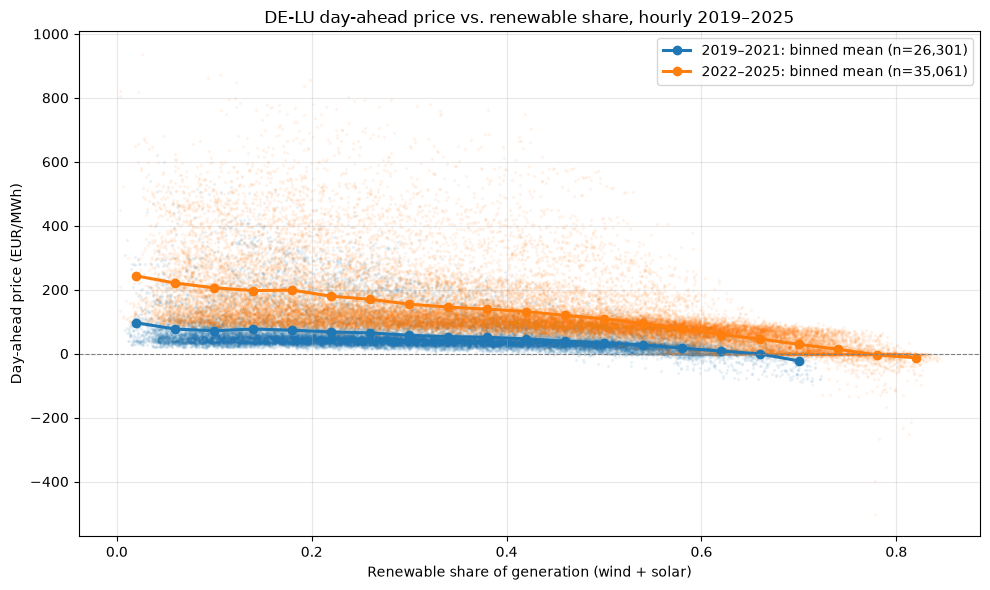

In [5]:
colors = {"2019–2021": "tab:blue", "2022–2025": "tab:orange"}
bins = np.linspace(0, 1, 26)

fig, ax = plt.subplots(figsize=(10, 6))
for p, d in df.groupby("period"):
    ax.scatter(d["renewable_share"], d["price"], s=2, alpha=0.06, color=colors[p], rasterized=True)
    g = d.groupby(pd.cut(d["renewable_share"], bins), observed=True)["price"].agg(["mean", "size"])
    g = g[g["size"] >= 50]
    mids = [iv.mid for iv in g.index]
    ax.plot(mids, g["mean"], marker="o", lw=2.2, color=colors[p], label=f"{p}: binned mean (n={len(d):,})")
ax.axhline(0, color="grey", lw=0.8, ls="--")
ax.set_xlabel("Renewable share of generation (wind + solar)")
ax.set_ylabel("Day-ahead price (EUR/MWh)")
ax.set_title("DE-LU day-ahead price vs. renewable share, hourly 2019–2025")
ax.legend(loc="upper right")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Regression
`price ~ renewable_share + residual_load + C(month) + C(hour)`, OLS (statsmodels) with Newey-West (HAC) standard
errors, Bartlett kernel, `HAC_MAXLAGS` hours. Estimated on the full sample, then separately on 2019–2021 and 2022–2025.

In [6]:
FORMULA = "price ~ renewable_share + residual_load + C(month) + C(hour)"

def fit_hac(d):
    d = d.sort_index()
    return smf.ols(FORMULA, data=d).fit(cov_type="HAC", cov_kwds={"maxlags": HAC_MAXLAGS})

full = fit_hac(df)
print(full.summary(title=f"Full sample 2019–2025, HAC (maxlags={HAC_MAXLAGS})"))

                   Full sample 2019–2025, HAC (maxlags=168)                   
Dep. Variable:                  price   R-squared:                       0.195
Model:                            OLS   Adj. R-squared:                  0.195
Method:                 Least Squares   F-statistic:                     35.26
Date:                Thu, 17 Sep 2026   Prob (F-statistic):          1.42e-240
Time:                        21:56:38   Log-Likelihood:            -3.5906e+05
No. Observations:               61362   AIC:                         7.182e+05
Df Residuals:                   61325   BIC:                         7.185e+05
Df Model:                          36                                         
Covariance Type:                  HAC                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          34.6472     22.283     

In [7]:
rows = []
for label, sample in [("Full 2019–2025", df)] + [(p, df[df["period"] == p]) for p in SUBPERIODS]:
    res = full if label.startswith("Full") else fit_hac(sample)
    v = "renewable_share"
    rows.append({"sample": label, "N": int(res.nobs), "coef": res.params[v], "HAC SE": res.bse[v],
                 "t": res.tvalues[v], "p-value": res.pvalues[v], "R²": res.rsquared})
comparison = pd.DataFrame(rows).set_index("sample")

print(f"renewable_share coefficient by sample (HAC, maxlags={HAC_MAXLAGS})")
display(comparison.round({"coef": 3, "HAC SE": 3, "t": 2, "p-value": 6, "R²": 3}))

renewable_share coefficient by sample (HAC, maxlags=168)


,N,coef,HAC SE,t,p-value,R²
sample,,,,,,
Full 2019–2025,61362,-64.037,30.254,-2.12,0.034288,0.195
2019–2021,26301,46.567,21.656,2.15,0.031530,0.341
2022–2025,35061,-220.274,40.149,-5.49,0.000000,0.420


## 6. Robustness checks
Each specification is estimated on the full sample and on both sub-periods; only the `renewable_share`
coefficient is reported.

1. **Baseline**: the model from Section 5.
2. **Total load instead of residual load**: `price ~ renewable_share + total_load + C(month) + C(hour)`,
   because residual load already subtracts wind and solar.
3. **HAC with 336 lags** (two weeks): sensitivity of the standard errors to the truncation lag.
4. **Year-month fixed effects** replace the month dummies, absorbing month-level shifts in fuel and CO₂ costs.
5. **Gas and CO₂ price controls** (optional): runs only if `data/fuel_prices.csv` exists, with daily columns
   `date, ttf, eua` (TTF gas in EUR/MWh, EUA in EUR/t). Values are forward-filled over non-trading days.
   The file is gitignored.

**Pooled interaction test.** Both sub-periods are pooled, and `renewable_share` and the load control are
interacted with `post2022` (1 for 2022–2025). The interaction coefficient is the difference in β₁ between the
periods, with a HAC standard error.

In [8]:
def fit_spec(formula, d, maxlags=HAC_MAXLAGS):
    d = d.sort_index()
    return smf.ols(formula, data=d).fit(cov_type="HAC", cov_kwds={"maxlags": maxlags})

SPECS = {
    "1 Baseline (residual load)":        ("price ~ renewable_share + residual_load + C(month) + C(hour)", HAC_MAXLAGS),
    "2 Total load instead of residual":  ("price ~ renewable_share + total_load + C(month) + C(hour)", HAC_MAXLAGS),
    "3 Baseline, HAC 336 lags":          ("price ~ renewable_share + residual_load + C(month) + C(hour)", 336),
    "4 Year-month FE":                   ("price ~ renewable_share + residual_load + C(year_month) + C(hour)", HAC_MAXLAGS),
}

FUEL_CSV = DATA_DIR / "fuel_prices.csv"
if FUEL_CSV.exists():
    fuel = pd.read_csv(FUEL_CSV, parse_dates=["date"]).set_index("date")[["ttf", "eua"]].sort_index()
    day = df["local_time"].dt.tz_localize(None).dt.normalize()
    fuel = fuel.reindex(pd.date_range(fuel.index.min(), day.max(), freq="D")).ffill()
    df["ttf"] = day.map(fuel["ttf"])
    df["eua"] = day.map(fuel["eua"])
    SPECS["5 Gas + CO2 price controls"] = (
        "price ~ renewable_share + residual_load + ttf + eua + C(month) + C(hour)", HAC_MAXLAGS)
    print(f"Fuel prices loaded from {FUEL_CSV}; hours without a fuel price: {df['ttf'].isna().sum():,}")
else:
    print(f"Spec 5 skipped: {FUEL_CSV} not found (optional).")

samples = [("Full 2019–2025", df)] + [(p, df[df["period"] == p]) for p in SUBPERIODS]
rows = []
for spec, (formula, lags) in SPECS.items():
    for label, d in samples:
        r = fit_spec(formula, d, lags)
        rows.append({"spec": spec, "sample": label, "N": int(r.nobs),
                     "coef": r.params["renewable_share"], "HAC SE": r.bse["renewable_share"],
                     "t": r.tvalues["renewable_share"], "p-value": r.pvalues["renewable_share"],
                     "R²": r.rsquared})
robustness = pd.DataFrame(rows).set_index(["spec", "sample"])

INTERACTIONS = {
    "residual-load spec": "price ~ renewable_share * post2022 + residual_load * post2022 + C(month) + C(hour)",
    "total-load spec":    "price ~ renewable_share * post2022 + total_load * post2022 + C(month) + C(hour)",
}
inter_rows = []
for name, formula in INTERACTIONS.items():
    r = fit_spec(formula, df)
    k = "renewable_share:post2022"
    inter_rows.append({"test": f"Δβ, {name}", "N": int(r.nobs),
                       "coef": r.params[k], "HAC SE": r.bse[k], "t": r.tvalues[k], "p-value": r.pvalues[k]})
interaction = pd.DataFrame(inter_rows).set_index("test")

fmt = {"coef": 3, "HAC SE": 3, "t": 2, "p-value": 6, "R²": 3}
print("Robustness: renewable_share coefficient (HAC)")
display(robustness.round(fmt))
print(f"Pooled interaction test: Δβ renewable_share = β(2022–2025) − β(2019–2021), HAC maxlags={HAC_MAXLAGS}")
display(interaction.round(fmt))

Spec 5 skipped: data/fuel_prices.csv not found (optional).


Robustness: renewable_share coefficient (HAC)


N     coef  HAC SE  \
spec                             sample                                   
1 Baseline (residual load)       Full 2019–2025  61362  -64.037  30.254   
                                 2019–2021       26301   46.567  21.656   
                                 2022–2025       35061 -220.274  40.149   
2 Total load instead of residual Full 2019–2025  61362 -177.331  15.059   
                                 2019–2021       26301 -118.335  14.069   
                                 2022–2025       35061 -312.117  20.312   
3 Baseline, HAC 336 lags         Full 2019–2025  61362  -64.037  38.947   
                                 2019–2021       26301   46.567  23.650   
                                 2022–2025       35061 -220.274  52.079   
4 Year-month FE                  Full 2019–2025  61362   -0.920   7.860   
                                 2019–2021       26301    5.406   7.491   
                                 2022–2025       35061   41.564  12.127   

                                                     t   p-value     R²  
spec                             sample                                  
1 Baseline (residual load)       Full 2019–2025  -2.12  0.034288  0.195  
                                 2019–2021        2.15  0.031530  0.341  
                                 2022–2025       -5.49  0.000000  0.420  
2 Total load instead of residual Full 2019–2025 -11.78  0.000000  0.193  
                                 2019–2021       -8.41  0.000000  0.334  
                                 2022–2025      -15.37  0.000000  0.453  
3 Baseline, HAC 336 lags         Full 2019–2025  -1.64  0.100128  0.195  
                                 2019–2021        1.97  0.048952  0.341  
                                 2022–2025       -4.23  0.000023  0.420  
4 Year-month FE                  Full 2019–2025  -0.12  0.906812  0.827  
                                 2019–2021        0.72  0.470514  0.815  
                                 2022–2025        3.43  0.000610  0.827

Pooled interaction test: Δβ renewable_share = β(2022–2025) − β(2019–2021), HAC maxlags=168


,N,coef,HAC SE,t,p-value
test,,,,,
"Δβ, residual-load spec",61362,-163.851,35.053,-4.67,0.000003
"Δβ, total-load spec",61362,-187.076,24.582,-7.61,0.000000
